datetime64[ns]
Region  Month  
East    January    1380.000000
North   January    1509.545455
South   January    2525.000000
West    January    2315.000000
Name: Sales, dtype: float64
  Region   Sales  Target
0   East  1380.0    5000
1   East  1380.0    3500
2   East  1380.0    7500
3   East  1380.0    2000
4   West  2315.0    4000
5   West  2315.0    8000
6   West  2315.0    6000
7   West  2315.0    6500
8   West  2315.0    4500
0    27.60
1    39.43
2    18.40
3    69.00
4    57.88
5    28.94
6    38.58
7    35.62
8    51.44
dtype: float64
Axes(0.125,0.11;0.775x0.77)


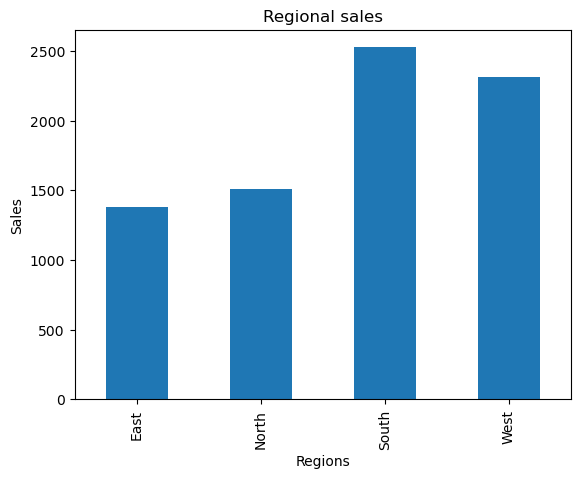

In [43]:
#First I will import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Next step I will load the dataset

df=pd.read_csv(r"C:\Users\Administrator\Downloads\retail_sales.csv")

df

#Next step I will Identify and Handle Missing Values

df.isnull().sum()

df["Sales"] = df["Sales"].fillna(df["Sales"].mean())
df["Quantity"]=df["Quantity"].fillna(df["Quantity"].median())  #I have Replaced the missing Quantity values with the median:
df["Discount"]=df["Discount"].fillna(df["Discount"].mean())

df.isnull().sum()

#Next step I will Fix Inconsistent or Incorrect Data
#I will Remove negative sales values:

df=df[df["Sales"]>=0] #I have filtered the negative sales

df


#Next step I will Standardize product names using string methods

df["Product"]=df["Product"].str.strip().str.title()

#Next step I will Convert Date to a datetime object: 

df["Date"]=pd.to_datetime(df["Date"])

print(df["Date"].dtype)

#Next step I will Extract new columns:

df["Month"]=df["Date"].dt.month_name()
df["Weekday"]=df["Date"].dt.day_name()

df

#Next step is aggregation and Grouping
#Finding the total Monthly sales per Region

Monthly_sales=df.groupby(["Region","Month"])["Sales"].sum()

print(Monthly_sales)

targets=pd.read_csv(r"C:\Users\Administrator\Downloads\targets.csv")

df2

#Now I will Merge it with the sales data:

merged=pd.merge(Monthly_sales,targets,on="Region", how="inner")

print(merged)

#Next I will calculate the perfomance

merged_perfomance=(merged["Sales"]/merged["Target"])*100

print(merged_perfomance.round(2))

#I will now export the cleaned Data

merged.to_csv(r"C:\Users\Administrator\Downloads\clean_merged_sales.csv", index=False)

#I will create a simple visualization of sales by Region using matplotlib

Region_sales=df.groupby("Region")["Sales"].sum().plot(kind="bar",ylabel="Sales",xlabel="Regions",title="Regional sales")

print(Region_sales)
